In [1]:
import relative_imports
import torch
device = torch.device("cuda:3")

In [2]:
from spatiotemporal.SEN12MSCRTS import DatasetManager

In [3]:
from os.path import join
from os import listdir
from datetime import datetime

In [4]:
root_dir = '/LOCAL2/shvl/datasets/cloud_removal/SEN12MSCRTS'
cloud_maps_dir = "/LOCAL2/shvl/datasets/cloud_removal/SEN12MSCRTS_cloud_maps"
dataset_manager = DatasetManager(
    root_dir=root_dir,
    cloud_maps_dir=cloud_maps_dir
)
# dataset_manager.load_dataset()
# dataset_manager.save_to_file()
dataset_manager.load_from_file()

In [5]:
utils = dataset_manager.utils

In [6]:
path_to_azuaga_s2 = "/LOCAL2/shvl/datasets/BWIRE/Azuaga/S2"
path_to_azuaga_s1 = "/LOCAL2/shvl/datasets/BWIRE/Azuaga/S1"

In [7]:
s2_images = [file for file in listdir(path_to_azuaga_s2) if file[:4] == "2019"]
s1_images = [file for file in listdir(path_to_azuaga_s1) if file[17:21] == "2019"]

In [8]:
s2_images[0][:8]

'20190810'

In [9]:
s1_days = {datetime.strptime(filename[17:25], "%Y%m%d").timetuple().tm_yday: filename for filename in s1_images}
s2_days = {datetime.strptime(filename[:8], "%Y%m%d").timetuple().tm_yday: filename for filename in s2_images}

In [10]:
s1_days = dict(sorted(s1_days.items()))
s2_days = dict(sorted(s2_days.items()))

In [11]:
s1_days

{5: 'S1A_IW_GRDH_1SDV_20190105T181853_20190105T181918_025346_02CE2C_80E0.tif',
 11: 'S1B_IW_GRDH_1SDV_20190111T181800_20190111T181825_014450_01AE7E_5C38.tif',
 17: 'S1A_IW_GRDH_1SDV_20190117T181852_20190117T181917_025521_02D47C_B066.tif',
 23: 'S1B_IW_GRDH_1SDV_20190123T181759_20190123T181824_014625_01B419_1A26.tif',
 29: 'S1A_IW_GRDH_1SDV_20190129T181852_20190129T181917_025696_02DAE6_DE59.tif',
 35: 'S1B_IW_GRDH_1SDV_20190204T181759_20190204T181824_014800_01B9CD_A370.tif',
 41: 'S1A_IW_GRDH_1SDV_20190210T181851_20190210T181916_025871_02E131_FE4B.tif',
 47: 'S1B_IW_GRDH_1SDV_20190216T181758_20190216T181823_014975_01BF86_19CF.tif',
 53: 'S1A_IW_GRDH_1SDV_20190222T181851_20190222T181916_026046_02E764_CBAD.tif',
 59: 'S1B_IW_GRDH_1SDV_20190228T181758_20190228T181823_015150_01C543_44C3.tif',
 65: 'S1A_IW_GRDH_1SDV_20190306T181851_20190306T181916_026221_02EDA6_D7E2.tif',
 71: 'S1B_IW_GRDH_1SDV_20190312T181758_20190312T181823_015325_01CB04_EE7E.tif',
 77: 'S1A_IW_GRDH_1SDV_20190318T181851_20

In [12]:
import numpy as np

In [13]:
s1_indices = []
s2_indices = []
anchors = np.linspace(6, 359, 30)

for anchor in anchors:
    s1_index = np.abs(np.asarray(list(s1_days.keys())) - anchor).argmin()
    s2_index = np.abs(np.asarray(list(s2_days.keys())) - anchor).argmin()
    s1_indices.append(list(s1_days.values())[s1_index])
    s2_indices.append(list(s2_days.values())[s2_index])

In [14]:
import pandas as pd

In [15]:
timesteps = pd.DataFrame(
    np.asarray([s1_indices, s2_indices]).T,
    columns=["S1", "S2"]
)

In [16]:
timesteps.to_csv("../config/Azuaga_timesteps.csv")

# Create dataset

In [17]:
path_to_azuaga_s2 = "/LOCAL2/shvl/datasets/BWIRE/Azuaga/S2"
path_to_azuaga_s1 = "/LOCAL2/shvl/datasets/BWIRE/Azuaga/S1"

timesteps = pd.read_csv("../config/Azuaga_timesteps.csv", index_col=0)
timesteps

,S1,S2
0,S1A_IW_GRDH_1SDV_20190105T181853_20190105T1819...,20190107T111439_20190107T111438_T30STH.tif
1,S1A_IW_GRDH_1SDV_20190117T181852_20190117T1819...,20190117T111409_20190117T111410_T30STH.tif
2,S1A_IW_GRDH_1SDV_20190129T181852_20190129T1819...,20190201T111301_20190201T111300_T30STH.tif
3,S1A_IW_GRDH_1SDV_20190210T181851_20190210T1819...,20190211T111201_20190211T111437_T30STH.tif
4,S1A_IW_GRDH_1SDV_20190222T181851_20190222T1819...,20190226T111049_20190226T111048_T30STH.tif
5,S1A_IW_GRDH_1SDV_20190306T181851_20190306T1819...,20190308T110909_20190308T111627_T30STH.tif
6,S1A_IW_GRDH_1SDV_20190318T181851_20190318T1819...,20190318T110759_20190318T112016_T30STH.tif
7,S1A_IW_GRDH_1SDV_20190330T181852_20190330T1819...,20190402T110621_20190402T110826_T30STH.tif
8,S1A_IW_GRDH_1SDV_20190411T181852_20190411T1819...,20190412T110621_20190412T112026_T30STH.tif
9,S1A_IW_GRDH_1SDV_20190423T181853_20190423T1819...,20190427T110629_20190427T111242_T30STH.tif


In [18]:
ROI = "ROIsAzuaga"
tile = 42

In [19]:
paths = {"S2": path_to_azuaga_s2, "S1": path_to_azuaga_s1}

In [20]:
target_path = "/LOCAL2/shvl/datasets/cloud_removal/AZUAGA"

# Create dataset

In [21]:
from osgeo import gdal
from os import makedirs
from tqdm import tqdm

In [22]:
from spatiotemporal.imagefile import ImageFile

In [23]:
from scipy.interpolate import NearestNDInterpolator

In [24]:
def _interpolate_zeros_inplace(image, nanmask):

    for band in range(image.shape[0]):
        band_image = image[band]
        zero_mask = nanmask[band]
        interpolator = NearestNDInterpolator(
            x=np.argwhere(~zero_mask),
            y=band_image[~zero_mask]
        )
        image[band, zero_mask] = interpolator(np.argwhere(zero_mask))

In [25]:
driver = gdal.GetDriverByName("GTiff")

In [26]:
for modality in ["S2", "S1"]:

    for timestep in tqdm(range(30)):

        filename = timesteps.loc[timestep, modality]
        filepath = join(paths[modality], filename)

        reader = gdal.Open(filepath)
        geotransform = gt = reader.GetGeoTransform()
        projection = reader.GetProjection()

        image = reader.ReadAsArray()
        rows = image.shape[1] // 256
        cols = image.shape[2] // 256

        for row in range(rows):
            for col in range(cols):
                
                patch = col + row*cols
                if modality == "S2":
                    date = datetime.strptime(filename[:8], "%Y%m%d").strftime("%Y-%m-%d")
                else:
                    date = datetime.strptime(filename[17:25], "%Y%m%d").strftime("%Y-%m-%d")
        
                outfile = ImageFile(root_dir=target_path, ROI=ROI, timestep=timestep, tile=tile, patch=patch, modality=modality, date=date)
                makedirs(outfile.directory, exist_ok=True)
                image_patch = image[:, 256*row:256*(row+1), 256*col:256*(col+1)]

                if modality == "S2":
                    nan_mask = image_patch == 0
                else:
                    nan_mask = np.isnan(image_patch)

                if nan_mask.sum() != 0:

                    print(f"Interpolating {filename}")

                    _interpolate_zeros_inplace(image_patch, nan_mask)

                new_geotransform = [
                    gt[0] + gt[1]*256*col,
                    gt[1],
                    0,
                    gt[3] + gt[5]*256*row,
                    0,
                    gt[5]
                ]

                output_writer = driver.Create(outfile.filepath, 256, 256, image_patch.shape[0], gdal.GDT_UInt16)
                output_writer.SetGeoTransform(new_geotransform)
                output_writer.SetProjection(projection)
                for band_num in range(image_patch.shape[0]):
                    output_writer.GetRasterBand(band_num + 1).WriteArray(image_patch[band_num])
                output_writer.FlushCache()  ## saves to disk!!
                output_writer = None
                donor_image_reader = None

 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                 | 27/30 [16:57<02:28, 49.37s/it]

Interpolating 20191203T111329_20191203T111436_T30STH.tif


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [02:40<00:00,  5.34s/it]


# Calculate cloud maps

In [1]:
import relative_imports
from spatiotemporal.SEN12MSCRTS import DatasetManager
from tqdm.notebook import tqdm

In [2]:
root_dir = '/LOCAL2/shvl/datasets/cloud_removal/AZUAGA'
cloud_maps_dir = "/LOCAL2/shvl/datasets/cloud_removal/AZUAGA_cloudmaps"
dataset_manager = DatasetManager(
    root_dir=root_dir,
    cloud_maps_dir=cloud_maps_dir
)
dataset_manager.load_dataset()

Extract paths to files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18360/18360 [00:00<00:00, 198242.30it/s]


In [3]:
dataset_manager.data

modality                                                                       S1  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

modality                                                                       S2  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

modality                                                               S2CLOUDMAP  
ROI        tile patch timestep                                                     
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
...                                                                           ...  
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  

[6120 rows x 3 columns]

In [ ]:
# Supress warnings from PyProj

sys.stderr = open(os.devnull, "w")
print("")

In [17]:
for index in tqdm(dataset_manager.data.index):
    dataset_manager.utils.get_cloud_map(
        index=index,
        try_load=False,
        overwrite=True
    )

  0%|          | 0/6120 [00:00<?, ?it/s]

# Create categorical cloud maps and cloud percentages

In [1]:
import relative_imports

In [2]:
from spatiotemporal.SEN12MSCRTS import DatasetManager
from spatiotemporal.imagefile import ImageFile
from os import makedirs
from osgeo import gdal
from torch.utils.data import Dataset
from tqdm import tqdm
from os.path import isfile, join
import numpy as np
import pandas as pd

In [3]:
root_dir = '/LOCAL2/shvl/datasets/cloud_removal/AZUAGA'
cloud_maps_dir = "/LOCAL2/shvl/datasets/cloud_removal/AZUAGA_cloudmaps"
dataset_manager = DatasetManager(
    root_dir=root_dir,
    cloud_maps_dir=cloud_maps_dir,
    cloud_probability_threshold=0.35
)
dataset_manager.load_dataset()

Extract paths to files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18360/18360 [00:00<00:00, 192026.01it/s]


In [4]:
dataset_manager.data

modality                                                                       S1  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

modality                                                                       S2  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

modality                                                               S2CLOUDMAP  
ROI        tile patch timestep                                                     
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
...                                                                           ...  
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_clo...  

[6120 rows x 3 columns]

In [5]:
class CategoricalCloudMapDataset(Dataset):

    driver = gdal.GetDriverByName("GTiff")

    def __init__(self, dataset_manager):
        self.data = dataset_manager.data
        self.root_dir = dataset_manager.root_dir
        self.cloud_detector = dataset_manager.cloud_detector
        self.cloud_histogram = pd.DataFrame(
            pd.NA,
            index=self.data.index,
            columns=np.arange(101)
        )

    def __getitem__(self, idx):

        sample = self.data.iloc[idx]
        filepath = sample["S2CLOUDMAP"]
        if filepath is np.nan:
            return

        outfile = ImageFile(filepath=filepath)
        outfile = outfile.set(root_dir=join(self.root_dir + "_MODS", "CategoricalCloudMaps__AZUAGA"))

        makedirs(outfile.directory, exist_ok=True)

        cloud_map_reader = gdal.Open(filepath, gdal.GA_ReadOnly)
        cloud_map_image = cloud_map_reader.ReadAsArray()
        rows, cols = cloud_map_image.shape

        categorical_cloud_map = self.cloud_detector.get_mask_from_prob(cloud_map_image, categorical=True, skip_novalue=True)
        self.cloud_histogram.iloc[idx] = np.bincount(categorical_cloud_map.flatten(), minlength=101)

        outdata = self.driver.Create(outfile.filepath, cols, rows, 1, gdal.GDT_Byte)
        outdata.SetGeoTransform(cloud_map_reader.GetGeoTransform())
        outdata.SetProjection(cloud_map_reader.GetProjection())
        outdata.GetRasterBand(1).WriteArray(categorical_cloud_map)
        outdata.FlushCache() ## saves to disk!!
        outdata = None
        cloud_map_reader = None

        return

    def __len__(self):
        return len(self.data)

In [7]:
categorical_dataset = CategoricalCloudMapDataset(dataset_manager=dataset_manager)

In [8]:
for sample_num, sample in enumerate(tqdm(categorical_dataset)):
    pass

categorical_dataset.cloud_histogram.to_csv(join(dataset_manager.project_directory, "stats", "cloud_probability_histogram_int__AZUAGA.csv"))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6120/6120 [00:29<00:00, 204.07it/s]


In [9]:
categorical_dataset.cloud_histogram

0      1      2      3     4     5     6    \
ROI        tile patch timestep                                              
ROIsAzuaga 42   0     0          0      2    696   2620  5408  7411  7679   
                      1          0      0      0      0     0     0     0   
                      2          0      0      0      0     0     0    19   
                      3          0      0      0      0     0     0     0   
                      4         79  18515  24557  13527  5575  1715   727   
...                             ..    ...    ...    ...   ...   ...   ...   
                203   25         0   9540  14399   9567  6309  4972  3460   
                      26         0   7197   9301   9981  6701  4618  3371   
                      27         0      0    400   2421  4336  5047  4937   
                      28         0      0      0      0     0     0     0   
                      29         0    748   5232   3152  2486  4596  4621   

                                 7     8     9    ...   91    92    93    94   \
ROI        tile patch timestep                    ...                           
ROIsAzuaga 42   0     0         8601  8019  6277  ...     0     0     0     0   
                      1            0     0     0  ...   487   517   682   900   
                      2           87   122   174  ...   987  1234  1293  1654   
                      3            0     0     0  ...  1086  1460  1834  2214   
                      4          362   169    89  ...     0     0     0     0   
...                              ...   ...   ...  ...   ...   ...   ...   ...   
                203   25        2711  2430  1490  ...    10    17    16    15   
                      26        3133  3102  2732  ...     0     0     0     0   
                      27        5008  4795  4450  ...     0     0     0     0   
                      28           0     0     0  ...     0     0     0     0   
                      29        4110  3807  4199  ...     0     0     0     0   

                                 95    96    97    98     99     100  
ROI        tile patch timestep                                        
ROIsAzuaga 42   0     0            0     0     0     0      0      0  
                      1         1122  1466  2054  5212  22309  21187  
                      2         1762  1816  2134  3183   6635    695  
                      3         2540  3500  4710  9063  20112   8076  
                      4            0     0     0     0      0      0  
...                              ...   ...   ...   ...    ...    ...  
                203   25          46     0     0     0      0      0  
                      26           0     0     0     0      0      0  
                      27           0     0     0     0      0      0  
                      28           0     0     0     0      0  65536  
                      29           0     0     0     0      0      0  

[6120 rows x 101 columns]

# Load Azuaga dataset

In [3]:
import relative_imports

In [4]:
from spatiotemporal.SEN12MSCRTS import DatasetManager
from spatiotemporal.imagefile import ImageFile
from spatiotemporal.mods import CategoricalCloudMaps, CloudfreeArea
from os import makedirs
from osgeo import gdal
from torch.utils.data import Dataset
from tqdm import tqdm
from os.path import isfile, join
import numpy as np
import pandas as pd

In [5]:
root_dir = '/LOCAL2/shvl/datasets/cloud_removal/AZUAGA'
cloud_maps_dir = "/LOCAL2/shvl/datasets/cloud_removal/AZUAGA_cloudmaps"
dataset_manager = DatasetManager(
    root_dir=root_dir,
    cloud_maps_dir=cloud_maps_dir,
    cloud_probability_threshold=0.35
)
dataset_manager.load_dataset()

Extract paths to files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18360/18360 [00:00<00:00, 196459.03it/s]


In [6]:
# Ad-hoc fix just to make it work
dataset_manager._modifications.append("ZeroPixelsS2")
dataset_manager._modifications

['ZeroPixelsS2']

In [7]:
CategoricalCloudMaps(dataset_manager=dataset_manager, name_postfix="AZUAGA").apply(verbose=True)

    Starting...
Adding categorical cloud maps...
    Done!
    Added to manager!


In [8]:
# Another ad-hoc fix
dataset_manager._modifications.append("CategoricalCloudMaps")
dataset_manager._modifications

['ZeroPixelsS2', 'CategoricalCloudMaps__AZUAGA', 'CategoricalCloudMaps']

In [9]:
CloudfreeArea(dataset_manager=dataset_manager, name_postfix="AZUAGA").apply(verbose=True)

    Starting...
Adding cloudfree area percentages for threshold 35...
    Done!
    Added to manager!


In [10]:
dataset_manager.data

modality                                                                       S1  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

modality                                                                       S2  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

modality                                                               S2CLOUDMAP  \
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   

modality                       CLOUDFREEAREA  
ROI        tile patch timestep                
ROIsAzuaga 42   0     0                  1.0  
                      1                  0.0  
                      2             0.285156  
                      3             0.008865  
                      4                  1.0  
...                                      ...  
                203   25            0.992432  
                      26                 1.0  
                      27            0.922409  
                      28                 0.0  
                      29            0.962646  

[6120 rows x 4 columns]

### Load basic dataset

In [11]:
from spatiotemporal.torch_datasets.base_dataset import BaseDataset

In [35]:
from matplotlib import pyplot as plt

In [15]:
dataset = BaseDataset(dataset_manager=dataset_manager)
dataset.data

t_shift                                                                         0  \
modality                                                                       S1   
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

t_shift                                                                            \
modality                                                                       S2   
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA/ROI...   

t_shift                                                                            \
modality                                                               S2CLOUDMAP   
ROI        tile patch timestep                                                      
ROIsAzuaga 42   0     0         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      1         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      2         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      3         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      4         /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
...                                                                           ...   
                203   25        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      26        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      27        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      28        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   
                      29        /LOCAL2/shvl/datasets/cloud_removal/AZUAGA_MOD...   

t_shift                                                                  
modality                       CLOUDFREEAREA                index_tuple  
ROI        tile patch timestep                                           
ROIsAzuaga 42   0     0                  1.0     (ROIsAzuaga, 42, 0, 0)  
                      1                  0.0     (ROIsAzuaga, 42, 0, 1)  
                      2             0.285156     (ROIsAzu

In [23]:
T5_dataset = dataset + dataset.shift(-1) + dataset.shift(-2) + dataset.shift(-3) + dataset.shift(-4) + dataset.shift(-5)
_ = T5_dataset.dropna()
len(T5_dataset)

5100

In [30]:
T5_dataset = T5_dataset.data[T5_dataset.data[(0, "CLOUDFREEAREA")] > 0.95]
len(T5_dataset)

3505

In [32]:
inputs_cloudfree_area = T5_dataset[[(-1, "CLOUDFREEAREA"), (-2, "CLOUDFREEAREA"), (-3, "CLOUDFREEAREA")]]
inputs_cloudfree_area

t_shift                                   -1            -2            -3
modality                       CLOUDFREEAREA CLOUDFREEAREA CLOUDFREEAREA
ROI        tile patch timestep                                          
ROIsAzuaga 42   0     6             0.048798           1.0      0.008865
                      8              0.84877           1.0      0.048798
                      9                  1.0       0.84877           1.0
                      10                 1.0           1.0       0.84877
                      11                 1.0           1.0           1.0
...                                      ...           ...           ...
                203   21                 1.0           1.0           1.0
                      22                 1.0           1.0           1.0
                      25            0.798523      0.111511           1.0
                      26            0.992432      0.798523      0.111511
                      29                 0.0      0.922409           1.0

[3505 rows x 3 columns]

In [34]:
inputs_cloudfree_area.mean(axis=1)

ROI         tile  patch  timestep
ROIsAzuaga  42    0      6           0.352554
                         8           0.632523
                         9            0.94959
                         10           0.94959
                         11               1.0
                                       ...   
                  203    21               1.0
                         22               1.0
                         25          0.636678
                         26          0.634155
                         29          0.640803
Length: 3505, dtype: object

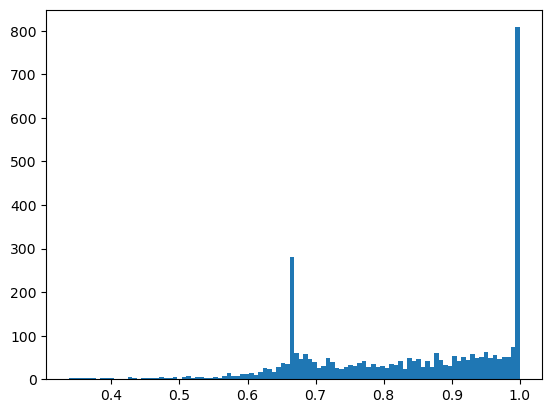

In [36]:
plt.hist(inputs_cloudfree_area.mean(axis=1), bins=100)
plt.show()

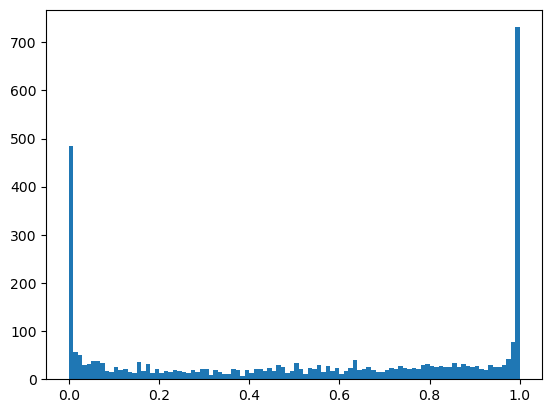

In [37]:
plt.hist(inputs_cloudfree_area.prod(axis=1), bins=100)
plt.show()

In [43]:
(inputs_cloudfree_area > 0.95).any(axis=1).mean()

0.9991440798858773